## Imports

In [1]:
import pandas as pd
import numpy as np

import xgboost as xgb
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.metrics import average_precision_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings("ignore")

## Metrics

In [2]:
def weighted_spearman(pred, true_eff, weights):
    pred_ranks = np.argsort(np.argsort(pred)).astype(float)
    true_ranks = np.argsort(np.argsort(true_eff)).astype(float)
    w = weights / weights.sum()
    mu_p, mu_t = np.dot(w, pred_ranks), np.dot(w, true_ranks)
    cov = np.sum(w * (pred_ranks - mu_p) * (true_ranks - mu_t))
    std_p = np.sqrt(np.sum(w * (pred_ranks - mu_p) ** 2))
    std_t = np.sqrt(np.sum(w * (true_ranks - mu_t) ** 2))
    return max(cov / (std_p * std_t), 0.0) if std_p > 1e-12 and std_t > 1e-12 else 0.0


def compute_cls(y_true, y_score, pe_eff):
    pr_auc = average_precision_score(y_true, y_score)
    w_spear = weighted_spearman(y_score, pe_eff, pe_eff + 0.01)
    if pr_auc > 0 and w_spear > 0:
        return 2 * pr_auc * w_spear / (pr_auc + w_spear), pr_auc, w_spear
    return 0.0, pr_auc, w_spear

## Load Data

In [3]:
train = pd.read_csv("/kaggle/input/competitions/retroviral-challenge-predict/train.csv")
test = pd.read_csv("/kaggle/input/competitions/retroviral-challenge-predict/test.csv")
print("Train shape", train.shape)
print("Test shape", test.shape)

Train shape (57, 71)
Test shape (57, 69)


## ESM-2 PCA

In [4]:
# Load and align ESM-2 embeddings
esm2_data = np.load(
    "/kaggle/input/competitions/retroviral-challenge-predict/esm2_embeddings.npz",
    allow_pickle=True,
)
esm2_dict = dict(zip(esm2_data["names"], esm2_data["embeddings"]))

train_embs = np.vstack([esm2_dict[name] for name in train["rt_name"]])
test_embs = np.vstack([esm2_dict[name] for name in test["rt_name"]])

# PCA (1280 dims -> 5 dims) to extract structure and prevent lineage memorization
pca = PCA(n_components=5, random_state=42)
train_pca = pca.fit_transform(train_embs)
test_pca = pca.transform(test_embs)

for i in range(5):
    train[f"pca_{i}"] = train_pca[:, i]
    test[f"pca_{i}"] = test_pca[:, i]

## New Features

In [5]:
BASE_FEATURES = [
    "foldseek_best_TM",
    "foldseek_best_fident",
    "foldseek_best_LDDT",
    "triad_best_rmsd",
    "D1_D2_dist",
    "pocket_hydrophobic_per_res",
    "camsol",
    "perplexity",
    "instability_index",
    "net_charge",
    "protein_length_aa",
]
PCA_FEATURES = [f"pca_{i}" for i in range(5)]


def engineer_features(df):
    df_feat = df.copy()

    # Missing active site = broken enzyme
    df_feat["is_broken_enzyme"] = df_feat["triad_best_rmsd"].isna().astype(int)

    # Structural density proxy
    df_feat["length_to_TM_ratio"] = df_feat["protein_length_aa"] / (df_feat["foldseek_best_TM"] + 1e-5)

    features = BASE_FEATURES + PCA_FEATURES + ["is_broken_enzyme", "length_to_TM_ratio"]
    X = df_feat[features].fillna(-999)
    return X, features


X_train, FINAL_FEATURES = engineer_features(train)
X_test, _ = engineer_features(test)

y_bin = train["active"]
y_eff = train["pe_efficiency_pct"]
families = train["rt_family"]

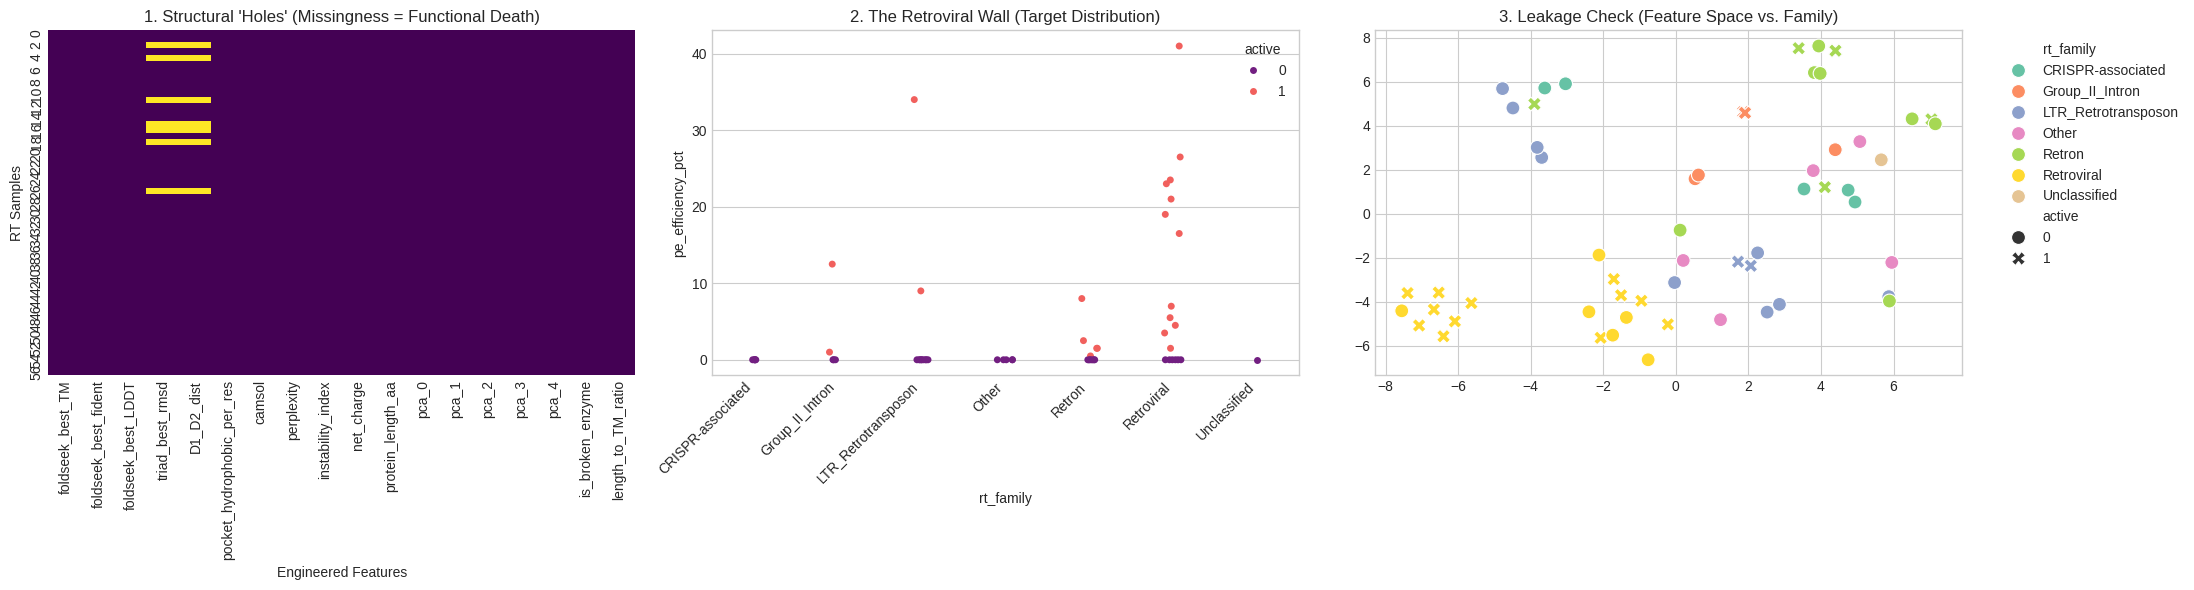

In [6]:
target = "pe_efficiency_pct"
family_col = "rt_family"

# Merge features and labels for plotting
eda_df = X_train.copy()
eda_df[[target, "active", family_col]] = train[[target, "active", family_col]]

# Recreate raw features to visualize true missingness before imputation
raw_df = train.copy()
raw_df["is_broken_enzyme"] = raw_df["triad_best_rmsd"].isna().astype(int)
raw_df["length_to_TM_ratio"] = raw_df["protein_length_aa"] / (raw_df["foldseek_best_TM"] + 1e-5)

plt.style.use("seaborn-v0_8-whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

# Missingness Heatmap
sns.heatmap(raw_df[FINAL_FEATURES].isnull(), cbar=False, cmap="viridis", ax=axes[0])
axes[0].set_title("1. Structural 'Holes' (Missingness = Functional Death)")
axes[0].set_xlabel("Engineered Features")
axes[0].set_ylabel("RT Samples")

# Target Distribution by Family
sns.stripplot(data=eda_df, x=family_col, y=target, hue="active", palette="magma", ax=axes[1])
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha="right")
axes[1].set_title("2. The Retroviral Wall (Target Distribution)")

# t-SNE Leakage Check
X_scaled = (X_train - X_train.mean()) / X_train.std()
X_embedded = TSNE(n_components=2, perplexity=15, random_state=42).fit_transform(X_scaled)

sns.scatterplot(
    x=X_embedded[:, 0],
    y=X_embedded[:, 1],
    hue=eda_df[family_col],
    style=eda_df["active"],
    s=100,
    palette="Set2",
    ax=axes[2],
)
axes[2].set_title("3. Leakage Check (Feature Space vs. Family)")
axes[2].legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()

## LOFO CV

In [7]:
oof_preds = np.zeros(len(train))
unique_families = families.unique()

for fam in unique_families:
    train_idx = families != fam
    test_idx = families == fam

    X_tr, y_bin_tr, y_eff_tr = (
        X_train.loc[train_idx],
        y_bin.loc[train_idx],
        y_eff.loc[train_idx],
    )
    X_te = X_train.loc[test_idx]
    active_mask = y_bin_tr == 1

    # XGBoost Hurdle
    xgb_clf = xgb.XGBClassifier(
        n_estimators=100,
        max_depth=1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric="logloss",
    )
    xgb_clf.fit(X_tr, y_bin_tr)
    xgb_prob = xgb_clf.predict_proba(X_te)[:, 1]

    xgb_reg = xgb.XGBRegressor(
        n_estimators=100,
        max_depth=1,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
    )
    if active_mask.sum() > 0:
        xgb_reg.fit(X_tr[active_mask], y_eff_tr[active_mask])
        xgb_eff = np.clip(xgb_reg.predict(X_te), 0, None)
    else:
        xgb_eff = np.zeros(len(X_te))

    xgb_preds = xgb_prob * xgb_eff

    # CatBoost Hurdle
    cb_clf = CatBoostClassifier(
        iterations=100,
        depth=1,
        learning_rate=0.05,
        verbose=False,
        random_seed=42
    )
    cb_clf.fit(X_tr, y_bin_tr)
    cb_prob = cb_clf.predict_proba(X_te)[:, 1]

    cb_reg = CatBoostRegressor(
        iterations=100,
        depth=1,
        learning_rate=0.05,
        verbose=False,
        random_seed=42
    )
    if active_mask.sum() > 0:
        cb_reg.fit(X_tr[active_mask], y_eff_tr[active_mask])
        cb_eff = np.clip(cb_reg.predict(X_te), 0, None)
    else:
        cb_eff = np.zeros(len(X_te))

    cb_preds = cb_prob * cb_eff

    # Ensemble Average
    oof_preds[test_idx] = (xgb_preds + cb_preds) / 2.0

cls, pr_auc, w_spear = compute_cls(y_bin, oof_preds, y_eff)
print(f"OOF PR-AUC: {pr_auc:.4f} | OOF W-Spearman: {w_spear:.4f} | OOF CLS: {cls:.4f}")

OOF PR-AUC: 0.6432 | OOF W-Spearman: 0.5405 | OOF CLS: 0.5874


## Full Training

In [8]:
active_mask_full = y_bin == 1

# Train Final XGBoost
xgb_clf_final = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric="logloss",
)
xgb_clf_final.fit(X_train, y_bin)
xgb_prob_test = xgb_clf_final.predict_proba(X_test)[:, 1]

xgb_reg_final = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=1,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
)
xgb_reg_final.fit(X_train[active_mask_full], y_eff[active_mask_full])
xgb_eff_test = np.clip(xgb_reg_final.predict(X_test), 0, None)
xgb_final_preds = xgb_prob_test * xgb_eff_test

# Train Final CatBoost
cb_clf_final = CatBoostClassifier(
    iterations=100,
    depth=1,
    learning_rate=0.05,
    verbose=False,
    random_seed=42
)
cb_clf_final.fit(X_train, y_bin)
cb_prob_test = cb_clf_final.predict_proba(X_test)[:, 1]

cb_reg_final = CatBoostRegressor(
    iterations=100,
    depth=1,
    learning_rate=0.05,
    verbose=False,
    random_seed=42
)
cb_reg_final.fit(X_train[active_mask_full], y_eff[active_mask_full])
cb_eff_test = np.clip(cb_reg_final.predict(X_test), 0, None)
cb_final_preds = cb_prob_test * cb_eff_test

## Submission

In [9]:
# Combine and Save
final_predictions = (xgb_final_preds + cb_final_preds) / 2.0

submission = pd.DataFrame({
    "rt_name": test["rt_name"],
    "predicted_score": final_predictions
})
submission.to_csv("submission.csv", index=False)
print("submission.csv successfully generated.")

submission.csv successfully generated.
